In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (LinearRegression,Ridge,Lasso)

from sklearn.ensemble import (RandomForestRegressor,GradientBoostingRegressor)

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

import joblib

In [3]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

In [4]:
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [5]:
print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values
Year                    0
Month                   0
Region                  0
Mo

In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Create Date Column
df["Date"]=pd.to_datetime(df["Year"].astype(str)+ "-"+ df["Month"].astype(str)+ "-01")

# Sort chronologically
df = df.sort_values("Date")

# Reset index
df.reset_index(drop=True, inplace=True)

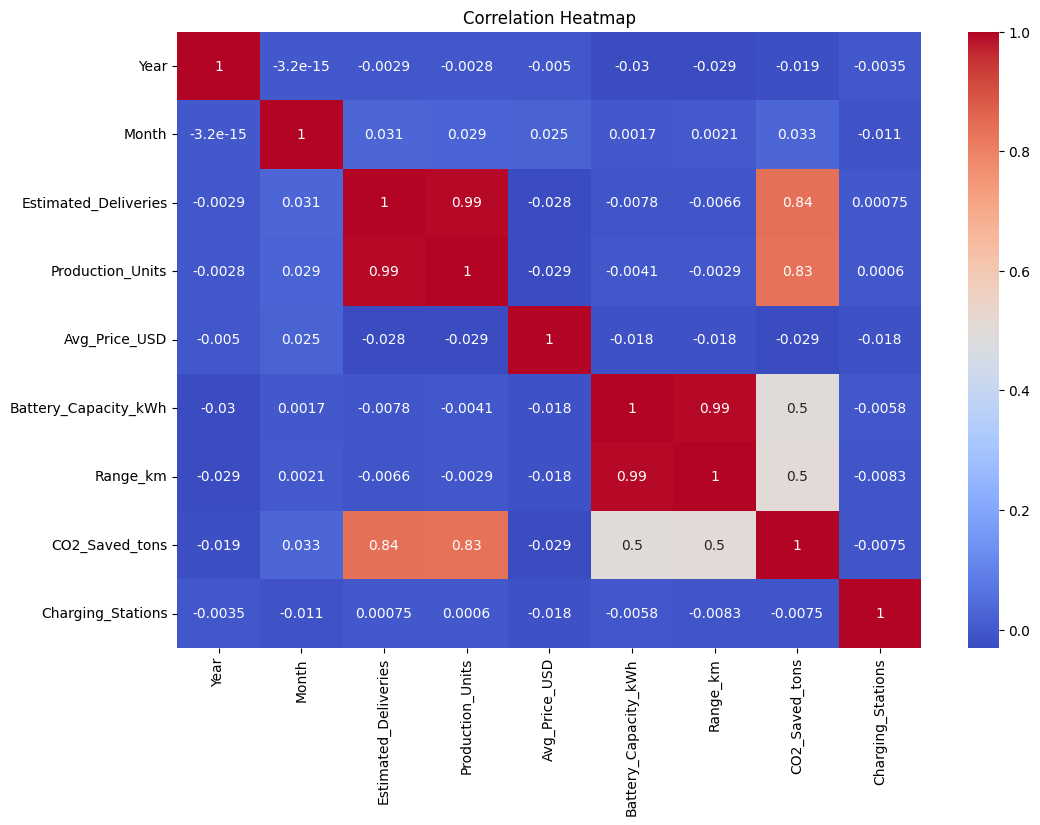

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
numeric_df=df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

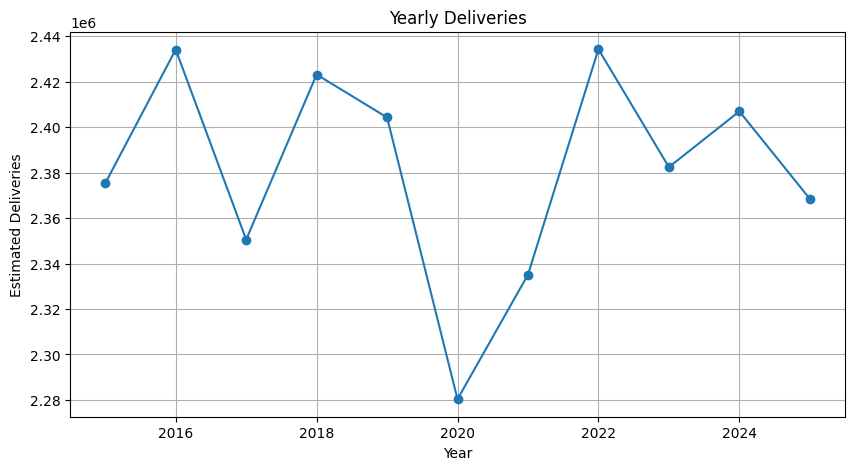

In [8]:
# Sales Trend Over Years
yearly_sales = df.groupby("Year")["Estimated_Deliveries"].sum()
plt.figure(figsize=(10,5))
plt.plot(yearly_sales.index,yearly_sales.values,marker='o')
plt.title("Yearly Deliveries")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

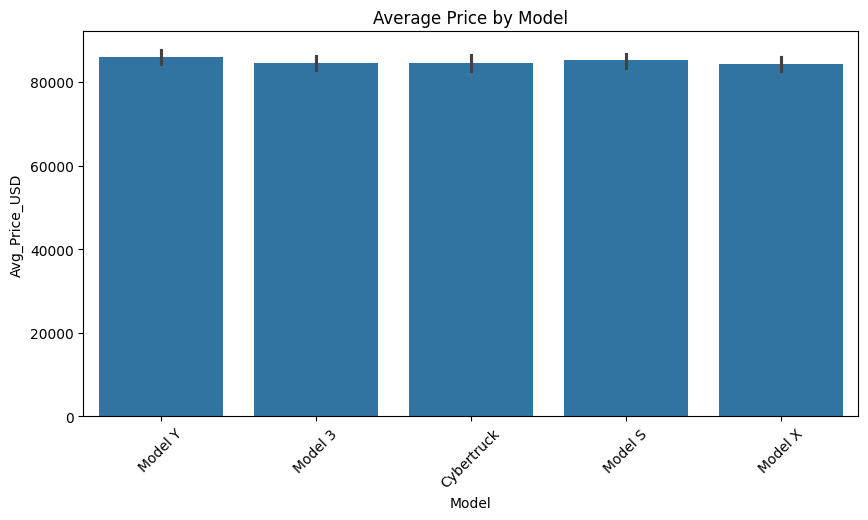

In [9]:
# Model-wise Average Price
plt.figure(figsize=(10,5))
sns.barplot(x="Model",y="Avg_Price_USD",data=df)
plt.title("Average Price by Model")
plt.xticks(rotation=45)
plt.show()

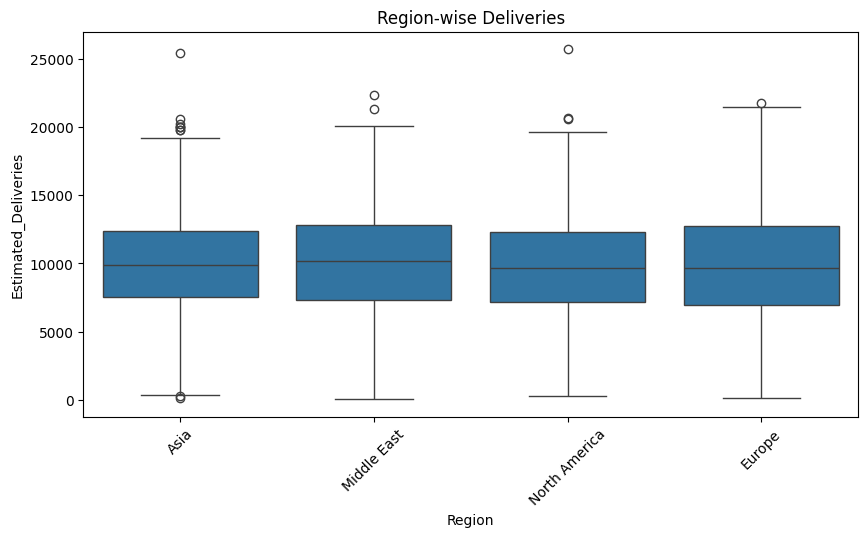

In [10]:
# Region-wise Deliveries
plt.figure(figsize=(10,5))
sns.boxplot(x="Region",y="Estimated_Deliveries",data=df)
plt.title("Region-wise Deliveries")
plt.xticks(rotation=45)
plt.show()

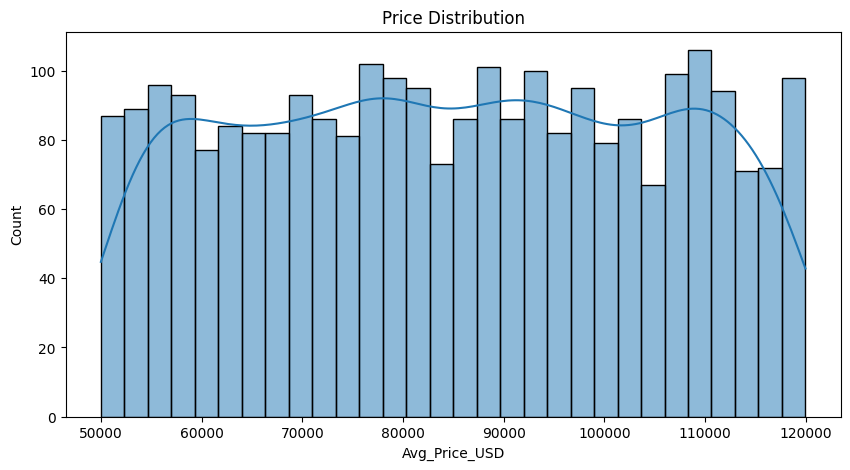

In [11]:
# Distribution Plot
plt.figure(figsize=(10,5))
sns.histplot(df["Avg_Price_USD"],bins=30,kde=True)
plt.title("Price Distribution")
plt.show()

In [12]:
# Feature engineering 
df["Quarter"]=df["Date"].dt.quarter
df["Month_Name"] = df["Date"].dt.month_name()
df["Revenue"] = (df["Estimated_Deliveries"]* df["Avg_Price_USD"])

# Lag Feature
df["Previous_Month_Delivery"]=(df["Estimated_Deliveries"].shift(1))

# Rolling Mean
df["Rolling_Mean_3"]=(df["Estimated_Deliveries"].rolling(window=3).mean())

# Fill generated NaNs
df.fillna(method="bfill",inplace=True)


In [13]:
# Define features and targets
X = df.drop(["Estimated_Deliveries", "Date"],axis=1)
y = df["Estimated_Deliveries"]

In [14]:
# Chronological Train test split
split_index = int(len(df) * 0.8)
X_train=X.iloc[:split_index]
X_test=X.iloc[split_index:]
y_train=y.iloc[:split_index]
y_test=y.iloc[split_index:]

In [15]:
#Preprocessing pipeline
numeric_features = X.select_dtypes(include=np.number).columns

categorical_features = X.select_dtypes(include="object").columns


# Numerical Pipeline
numeric_transformer=Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]
)

# Categorical Pipeline
categorical_transformer=Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Column Transformer
preprocessor=ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [16]:
# Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [17]:
# Train and evaluate models
results = {}
for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results[name] = r2

    print("\n============================")
    print(name)
    print("============================")

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)



Linear Regression
MAE: 286.1908242296791
RMSE: 354.66554168275724
R2 Score: 0.990539104742775

Ridge Regression
MAE: 285.59829449706444
RMSE: 354.50088752964825
R2 Score: 0.9905478871809485

Lasso Regression
MAE: 285.9571704784456
RMSE: 353.8808348858504
R2 Score: 0.9905809233860461

Random Forest
MAE: 321.77350378787884
RMSE: 401.1679882446191
R2 Score: 0.9878955019660791

Gradient Boosting
MAE: 328.97231129338644
RMSE: 398.33947289639553
R2 Score: 0.9880655906041572


In [18]:
# Cross Validation
rf_pipeline=Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)
cv_scores=cross_val_score(rf_pipeline,X,y,cv=5,scoring="r2")
print("\nCross Validation Scores")
print(cv_scores)

print("\nAverage CV Score")
print(cv_scores.mean())


Cross Validation Scores
[0.9880498  0.99049231 0.98931076 0.98968321 0.9878955 ]

Average CV Score
0.9890863160966841


In [19]:
# Hyper parameter Tuning
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, 10],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(rf_pipeline,param_grid,cv=3,scoring="r2",n_jobs=-1)
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_


Best Parameters
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [20]:
# Final Model Evaluation
final_predictions=best_model.predict(X_test)
print("\nFinal Tuned Random Forest Results")

print("MAE:",mean_absolute_error(y_test, final_predictions))
print("RMSE:",np.sqrt(mean_squared_error(y_test, final_predictions)))
print("R2 Score:",r2_score(y_test, final_predictions))


Final Tuned Random Forest Results
MAE: 326.42264397553055
RMSE: 405.230967258261
R2 Score: 0.9876490746887722


In [21]:
# Feature Importance
rf_model = best_model.named_steps["model"]
encoded_features = list(
    best_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)
all_features=(list(numeric_features)+ encoded_features)
importance_df=pd.DataFrame({"Feature": all_features,"Importance": rf_model.feature_importances_})
importance_df=importance_df.sort_values(by="Importance",ascending=False)
print("\nTop Important Features")
print(importance_df.head(10))


Top Important Features
                    Feature  Importance
2          Production_Units    0.992193
6            CO2_Saved_tons    0.001526
9                   Revenue    0.001147
5                  Range_km    0.000698
11           Rolling_Mean_3    0.000659
3             Avg_Price_USD    0.000620
7         Charging_Stations    0.000596
10  Previous_Month_Delivery    0.000567
0                      Year    0.000335
1                     Month    0.000287


In [22]:
# Time Series Analysis
ts_data=df.groupby("Date")["Estimated_Deliveries"].sum()
ts_data=ts_data.asfreq("MS")

In [23]:
# Stationarity Test
result=adfuller(ts_data)
print("\nADF Statistic:", result[0])
print("p-value:", result[1])
if result[1]<0.05:
    print("Stationary Time Series")
else:
    print("Non-Stationary Time Series")


ADF Statistic: -8.880990349502861
p-value: 1.3181396968154354e-14
Stationary Time Series


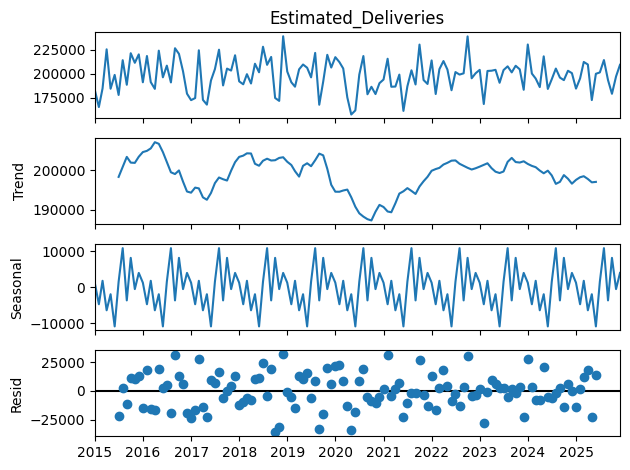

In [24]:
# Seasonal Decomposition
decomposition=seasonal_decompose(ts_data,model="additive",period=12)
decomposition.plot()
plt.show()

In [25]:
# ARIMA Forecasting
arima_model=ARIMA(ts_data,order=(1,1,1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Fri, 15 May 2026   AIC                           2983.269
Time:                          20:31:13   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   1.93e-11   1

In [26]:
# Future forecast
forecast=arima_fit.forecast(steps=12)
print("\nNext 12 Months Forecast")
print(forecast)


Next 12 Months Forecast
2026-01-01    201130.711312
2026-02-01    199815.368230
2026-03-01    199605.917024
2026-04-01    199572.564655
2026-05-01    199567.253726
2026-06-01    199566.408030
2026-07-01    199566.273364
2026-08-01    199566.251920
2026-09-01    199566.248506
2026-10-01    199566.247962
2026-11-01    199566.247875
2026-12-01    199566.247862
Freq: MS, Name: predicted_mean, dtype: float64


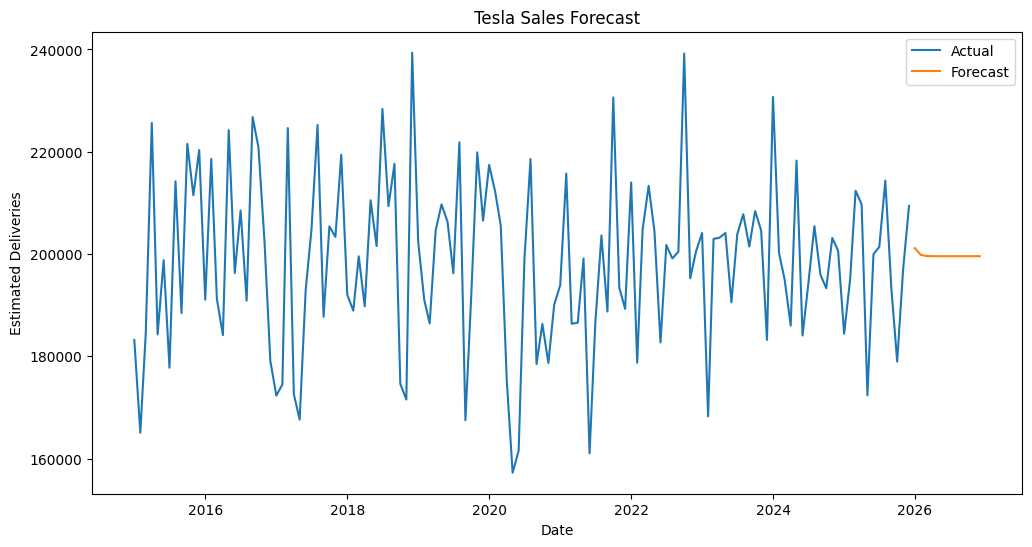

In [27]:
# Forecast Plot
plt.figure(figsize=(12,6))
plt.plot(ts_data.index,ts_data.values,label="Actual")
future_dates=pd.date_range(start=ts_data.index[-1],periods=12,freq="M")
plt.plot(future_dates,forecast,label="Forecast")
plt.title("Tesla Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()


In [28]:
# Save model
joblib.dump(
    best_model,
    "tesla_sales_model.pkl"
)
print("\nModel Saved Successfully")


Model Saved Successfully
